<a href="https://colab.research.google.com/github/Thashmikab/offshore-wind-layout-cable-tradeoff/blob/main/06_multiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q py_wake==2.6.20 topfarm==2.6.2 pymoo==0.6.2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 22.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.2/347.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [29]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
import numpy as np
import xarray as xr
from py_wake.site import XRSite
from py_wake.site.xrsite import GlobalWindAtlasSite
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.literature.gaussian_models import Niayifar_PorteAgel_2016
from py_wake.wind_farm_models import PropagateDownwind
from py_wake.turbulence_models import CrespoHernandez
#from py_wake.wind_farm_models import EngineeringWindFarmModel
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import Problem


In [18]:
#@title Wind farm variables

N_TURBINES = 8
TURBINE_DIAMETER = 178.3  # DTU 10MW Rotor Diameter (m)
MIN_SPACING = 4 * TURBINE_DIAMETER
wt = DTU10MW()
TI = 0.06
LIFETIME_YEARS = 25
single_turbine_cap = 10.0 # MW

LEASE_X, LEASE_Y = 3000, 2000
D_REF_KM = 146.65                   # GWA Dogger Bank point, measured from the coast at Flamborough Head
D_MIN_KM, D_MAX_KM = 10, 150
POP_SIZE, N_GEN, SEED = 80, 100, 1

In [31]:
#@title Economic values - Turbine


# Equipment Procurement CAPEX (per MW / per unit)
TURBINE_COST_PER_MW = 1_250_000   # Includes Nacelle + Rotor + steel tower
JACKET_COST_PER_MW  = 450_000     # Deeper water jacket structure (£450k/MW)

cost_per_turbine_station = (
    (TURBINE_COST_PER_MW * single_turbine_cap) +
    (JACKET_COST_PER_MW * single_turbine_cap)
)

array_station_capex = N_TURBINES * cost_per_turbine_station


# Operational Expenditures (OPEX)
COST_OPEX_PER_MW_YEAR = 75_000    # Logistics, heavy lift vessels, marine servicing base

# Lifetime & Financial Discount Factors
DISCOUNT_RATE = 0.065             # 6.5% Weighted Average Cost of Capital (WACC)

# Calculate Present Value Factor for OPEX and AEP over 25 years
# PV_factor = sum(1 / (1 + r)^t) for t from 1 to 25
PV_FACTOR = sum(1 / ((1 + DISCOUNT_RATE)**t) for t in range(1, LIFETIME_YEARS + 1))


In [20]:
#@title Economic values - Cables

# Cable Economic Model: Unit Costs (£ per Kilometer)

# 1. 66kV Inter-Array Metrics (Supply vs Total Installed)
COST_ARRAY_SUPPLY_PER_KM = 300_000
COST_ARRAY_INSTALLED_PER_KM = 750_000

# 2. Export Cable Metrics (Dependent on Offshore Distance)
# Close to shore (<100km): use 220kV HVAC proxy
COST_EXPORT_HVAC_PER_KM = 2_000_000

# Deep North Sea (>100km like Dogger Bank): use 320kV HVDC proxy
COST_EXPORT_HVDC_PER_KM = 3_200_000

In [4]:
DATA = Path("data/dogger_bank_gwa.nc")

def load_dogger_bank_site():
    """Dogger Bank wind climate from the Global Wind Atlas (54.75 N, 1.90 E, 119 m, open sea).
    Downloaded once and cached in data/ so later runs don't depend on the GWA API."""
    if DATA.exists():
        return XRSite(xr.load_dataset(DATA))
    print("Downloading Dogger Bank wind climate from the Global Wind Atlas...")
    site = GlobalWindAtlasSite(lat=54.75, long=1.90, height=119, roughness=0.0002)
    DATA.parent.mkdir(exist_ok=True)
    site.ds.to_netcdf(DATA)
    return site


base_gwa_site = load_dogger_bank_site()

In [5]:
# 1. Load the CSV file once
transect_df = pd.read_csv("https://raw.githubusercontent.com/Thashmikab/offshore-wind-layout-cable-tradeoff/refs/heads/main/data/dogger_bank_transect.csv")

# Extract arrays for blazing-fast numpy operations
KNOWN_DISTANCES = transect_df['distance_km'].values
KNOWN_SCALES    = transect_df['U_rel'].values

def calculate_transect_scale_factor(distance_to_shore_km):
    """
    Empirically scales wind speed based on a Global Wind Atlas transect
    running from the Yorkshire coast out to Dogger Bank.
    """
    # Clip the incoming distance to ensure safe lookup bounds [0, 160]
    query_dist = np.clip(distance_to_shore_km, KNOWN_DISTANCES[0], KNOWN_DISTANCES[-1])

    # Linearly interpolate the scaling factor
    scale_factor = np.interp(query_dist, KNOWN_DISTANCES, KNOWN_SCALES)
    return float(scale_factor)


#print(calculate_transect_scale_factor(10))


In [6]:
# Instantiate the wake physics engine

wind_farm_model = Niayifar_PorteAgel_2016(
    site=base_gwa_site,
    windTurbines=wt,
    turbulenceModel=CrespoHernandez() # Matches the Niayifar 2016 publication standard
)

In [32]:
#@title Objective function



def evaluate_wind_farm_layout(variables):
    """
    Objective function for NSGA-II 3-objective optimization.
    """

    # 1. Unpack variables
    x_coords = np.array(variables[0:N_TURBINES])
    y_coords = np.array(variables[N_TURBINES:2 * N_TURBINES])
    dist_shore_km = variables[-1]

    coords = np.column_stack((x_coords, y_coords))
    # Compute the pairwise Euclidean distances
    # This returns a compressed, flat array of all distinct pairs
    distances = pdist(coords)




    # OBJECTIVE 1: Minimize (-AEP)
    # Scale the Weibull A parameter (which sets the mean wind speed) by the transect factor

    scale_factor = calculate_transect_scale_factor(dist_shore_km)
    scaled_ds = base_gwa_site.ds.copy(deep=True)
    scaled_ds["Weibull_A"] = base_gwa_site.ds["Weibull_A"] * scale_factor
    scaled_ds["TI"] = TI
    wind_farm_model.site = XRSite(scaled_ds)


    x_offshore = x_coords + dist_shore_km * 1000
    aep_gwh = wind_farm_model(x_offshore, y_coords).aep().sum().values
    obj_energy = -aep_gwh






    # OBJECTIVE 2: Minimize Total Cost


    # Compute Minimum Spanning Tree of the turbine nodes
    dist_matrix = squareform(distances)
    mst_graph = minimum_spanning_tree(dist_matrix)      # calculates the path that connects all 8 turbines together such that the total length of the path is as short as possible, without creating any closed loops.
    array_cable_km = mst_graph.toarray().sum() / 1000.0 # Convert meters to km

    obj_array_cost = array_cable_km * COST_ARRAY_INSTALLED_PER_KM



    # Export cable cost
    export_cable_km = dist_shore_km
    obj_export_cost = export_cable_km * COST_EXPORT_HVAC_PER_KM


    # Total Turbine cost
    obj_turbine_cost = array_station_capex


    # OPEX
    annual_opex = COST_OPEX_PER_MW_YEAR * single_turbine_cap * N_TURBINES
    obj_opex = annual_opex * PV_FACTOR




    # Calculate the Levelised Cost of Energy (LCOE)

    aep_mwh = aep_gwh * 1000.0
    lifetime_generation_mwh = aep_mwh * PV_FACTOR

    total_cost_capital = obj_turbine_cost + obj_array_cost + obj_export_cost + obj_opex

    obj_lcoe = (total_cost_capital) / lifetime_generation_mwh





    # Constraint: closest pair must be at least MIN_SPACING apart (<= 0 means OK)
    spacing_violation = MIN_SPACING - distances.min()





    return [obj_energy, obj_lcoe], spacing_violation

In [52]:
#@title Test the objective function on the starting grid

x0 = np.linspace(0, 2400, 4).repeat(2)
y0 = np.tile(np.linspace(0, 800, 2), 4)

test_layout = np.concatenate([x0, y0, [75]])    # 4x2 grid, 50 km offshore
objectives, violation = evaluate_wind_farm_layout(test_layout)

print(f"AEP:          {-objectives[0]:.1f} GWh")
print(f"Total cost:   £{objectives[1]:.2f} per MWh")
#print(f"Export cost:  £{objectives[2] / 1e6:.1f}M")
print(f"Spacing OK:   {violation <= 0}")

AEP:          377.3 GWh
Total cost:   £78.95 per MWh
Spacing OK:   True


In [43]:
#@title NSGA-II problem

class WindFarmProblem(ElementwiseProblem):

    def __init__(self):
        lower = [0] * N_TURBINES + [0] * N_TURBINES + [D_MIN_KM]              # x, y, distance
        upper = [LEASE_X] * N_TURBINES + [LEASE_Y] * N_TURBINES + [D_MAX_KM]
        super().__init__(n_var=2 * N_TURBINES + 1,   # 17 variables
                         n_obj=2,              # energy, array cost, export cost
                         n_ieq_constr=1,       # spacing
                         xl=lower, xu=upper)

    def _evaluate(self, v, out, *args, **kwargs):
        objectives, spacing_violation = evaluate_wind_farm_layout(v)
        out["F"] = objectives
        out["G"] = [spacing_violation]

In [54]:
#@title Run NSGA-II

problem = WindFarmProblem()

# Starting population: random layouts, plus the 4x2 grid so at least one is feasible
rng = np.random.default_rng(SEED)
X0 = rng.uniform(problem.xl, problem.xu, size=(POP_SIZE, problem.n_var))
X0[0] = np.concatenate([x0, y0, [D_REF_KM]])

result = minimize(problem,
                  NSGA2(pop_size=POP_SIZE, sampling=X0),
                  ("n_gen", N_GEN),
                  seed=SEED,
                  verbose=True)        # prints progress each generation


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       80 |      1 |  0.000000E+00 |  4.564517E+02 |             - |             -
     2 |      160 |      1 |  0.000000E+00 |  3.513629E+02 |  2.798737E+01 |         ideal
     3 |      240 |      1 |  0.000000E+00 |  2.991185E+02 |  0.000000E+00 |             f
     4 |      320 |      2 |  0.000000E+00 |  2.443444E+02 |  1.0000000000 |         ideal
     5 |      400 |      2 |  0.000000E+00 |  2.056302E+02 |  0.000000E+00 |             f
     6 |      480 |      2 |  0.000000E+00 |  1.626812E+02 |  0.000000E+00 |             f
     7 |      560 |      2 |  0.000000E+00 |  1.134724E+02 |  0.000000E+00 |             f
     8 |      640 |      2 |  0.000000E+00 |  4.831911E+01 |  0.000000E+00 |             f
     9 |      720 |      2 |  0.000000E+00 |  6.8632703999 |  0.000000E+00 |             f
    10 |      800 |      3 |  0.000000E+00 |  0.4404330970 |  0.0338059088 |         ideal

In [55]:
#@title Get the full pareto front

front = pd.DataFrame({
    "Distance_to_shore_km": result.X[:, -1],
    "AEP_GWh":              -result.F[:, 0],
    "LCOE_GBP_MWh":     result.F[:, 1],
#    "Export_cost_GBP_M":    result.F[:, 2] / 1e6,
}).sort_values("Distance_to_shore_km").reset_index(drop=True)

print(f"{len(front)} trade-off layouts found")
print(front.round(1).to_string())

80 trade-off layouts found
    Distance_to_shore_km  AEP_GWh  LCOE_GBP_MWh
0                   10.0    364.4          52.9
1                   10.5    364.9          53.0
2                   11.1    365.5          53.2
3                   11.3    365.7          53.3
4                   11.9    366.2          53.5
5                   12.5    366.6          53.7
6                   13.1    367.1          53.9
7                   14.3    368.0          54.2
8                   14.8    368.5          54.4
9                   15.6    369.0          54.7
10                  15.8    369.0          54.8
11                  17.2    370.1          55.2
12                  17.6    370.3          55.4
13                  18.1    370.5          55.6
14                  18.5    371.0          55.7
15                  19.8    371.8          56.1
16                  20.3    372.2          56.3
17                  21.0    372.6          56.5
18                  21.6    373.0          56.7
19           

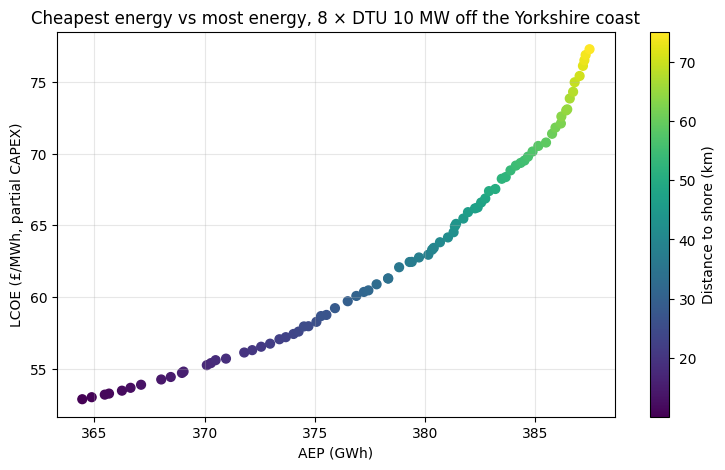

In [56]:
#@title Pareto front: LCOE vs AEP

plt.figure(figsize=(9, 5))
sc = plt.scatter(front.AEP_GWh, front.LCOE_GBP_MWh, c=front.Distance_to_shore_km, cmap="viridis", s=40)
plt.colorbar(sc, label="Distance to shore (km)")
plt.xlabel("AEP (GWh)"); plt.ylabel("LCOE (£/MWh, partial CAPEX)")
plt.title("Cheapest energy vs most energy, 8 × DTU 10 MW off the Yorkshire coast")
plt.grid(True, alpha=0.3)
#plt.savefig(FIG / "06_pareto_lcoe_aep.png", dpi=150, bbox_inches="tight")
plt.show()